# Mini Project 3

By the deadline, please submit the provided Jupyter notebook with all/some required tasks completed and clearly solved. Make sure your code is neat, well-commented, and that all outputs are visible (run all cells before saving). Notebooks with missing tasks or unexecuted cells may receive fewer points. After you submit, you won’t be able to make changes, so double-check your work and be sure to start from the provided template

## Submission rules
As already discussed in class, we will stick to the following rules.
- Use the templates and name your files `NAME_SURNAME.ipynb` (If you have more than one name, just concatenate them). We will compare what you present with that file. 
- Code either not written in Python or not using PyTorch receives a grade of 0. Of course, you can use auxiliary packages when needed (`matplotlib`, `numpy`, ...), but for the learning part, you must use PyTorch.
-  If plagiarism is suspected, TAs and I will thoroughly investigate the situation, and we will summon the student for a face-to-face clarification regarding certain answers they provided. In case of plagiarism, a score reduction will be applied to all the people involved, depending on their level of involvement.
-  If extensive usage of AI tools is detected, we will summon the student for a face-to-face clarification regarding certain answers they provided. If the answers are not adequately supported with in-person answers, we will proceed to apply a penalty to the evaluation, ranging from 10% to 100%.

## Sentiment Analysis with LSTM

The IMDb dataset is a large collection of movie reviews compiled by the Internet Movie Database (IMDb), one of the most comprehensive online databases for films, TV shows, actors, and production crew information. IMDb is widely used for accessing details such as cast lists, user ratings, reviews, and plot summaries [(source)](https://www.geeksforgeeks.org/data-science/imdb-datasets-types-usages-and-application/).

In this mini-project, you will perform **sentiment analysis** on IMDb movie reviews using **LSTM-based models**. The goal is to classify each review as positive or negative.

You are required to build and train:

* A **simple LSTM model**, aiming for at least **75% test accuracy**
* A **more advanced LSTM model**, trying to push the accuracy as high as possible
* A **function** that can evaluate the sentiment of any new review

In [1]:
# Packages here 
from datasets import load_dataset
import torch
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Don't change this 
torch.manual_seed(123)
torch.cuda.manual_seed(123)
np.random.seed(123)
torch.backends.cudnn.enabled=False
torch.backends.cudnn.deterministic=True

### Task 1 (0 pts)

To load the data, we will use [Hugging Face](https://huggingface.co/), an open-source platform that provides datasets, pre-trained models, and tools for modern machine learning.
**Note:** In principle, you could also use [TorchText](https://docs.pytorch.org/text/main/datasets.html#imdb), but it does not work reliably on Kaggle. Using PyTorch’s dataset instead of Hugging Face is **not** considered an error.

Inspect the dataset you load and make sure you understand its structure and format.

In [2]:
ds = load_dataset("stanfordnlp/imdb")
dataset_train = ds['train']
dataset_test = ds['test']

In [3]:
dataset_test

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})

In [4]:
dataset_train

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})

In [5]:
print(dataset_test[0])
print(dataset_test.data)

{'text': 'I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn\'t match the background, and painfully one-dimensional characters cannot be overcome with a \'sci-fi\' setting. (I\'m sure there are those of you out there who think Babylon 5 is good sci-fi TV. It\'s not. It\'s clichéd and uninspiring.) While US viewers might like emotion and character development, sci-fi is a genre that does not take itself seriously (cf. Star Trek). It may treat important issues, yet not as a serious philosophy. It\'s really difficult to care about the characters here as they are not simply foolish, just missing a spark of life. Their actions and reactions are wooden and predictable, often painful to watch. The makers of Earth KNOW it\'s rubbish as 

In [6]:
type(dataset_test)

datasets.arrow_dataset.Dataset

In [7]:
for x in dataset_train["label"]:
    print(x)
    break

0


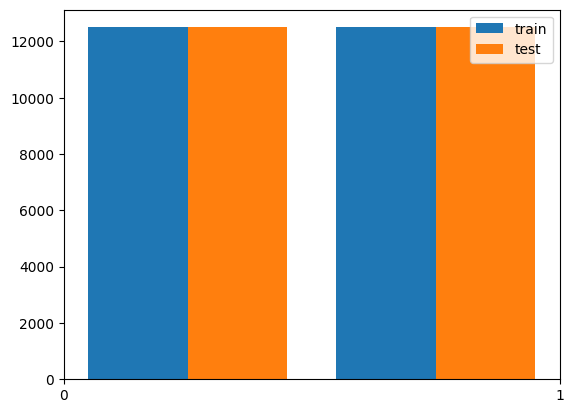

In [8]:
plt.hist([dataset_train["label"], dataset_test["label"]], label=['train', 'test'], bins=2)
plt.legend(loc='best')
plt.xticks(range(2))
plt.show()

### Task 2 (5 pts)

Split the original **test set** into two parts: a **validation set** and a **final test set**. Use a split of 50-50.

**Note:** We are aware that, in a typical machine learning workflow, you would split the **training set** (not the test set) to create a validation set. However, in this exercise, we intentionally use the test set for this purpose to provide you with **more training data** for model learning.

In [9]:
dataset_val, dataset_test = dataset_test.train_test_split(0.5).values()

In [10]:
print("Dataset Val length:", len(dataset_val))
print("Dataset Test length:", len(dataset_test))

Dataset Val length: 12500
Dataset Test length: 12500


### Task 3 (10 pts)

Create a `tokenize` function that takes a line from your dataset (a review) and converts it into tokens.
You may want to consider the following:

* Are `film` and `film.` considered different?
* Does it matter if a word is uppercase or lowercase?
* Should tokens like `<br />` be included or removed?

In [11]:
[x for x in dataset_test if ":)" in x['text'] or ":(" in x['text']]

[{'text': "This film was original in an unoriginal way. Although many movies have tackled the subject of suicide and mental institutions, it was always about treating the patients and making them better because of the doctor's assistance, in this film, however, we follow a depressed guy who falls in love with a suicidal girl and will stop at nothing to make her happy even though she doesn't care for happiness at all, she just wants to die. This was a very interestingly cute romance comedy that in nothing less than enjoyable. This is a fun one to check out if you ever get the chance, you just have to be open minded about the material. Overall i give it a 6.4, i just voted 9 to get the rating higher :)",
  'label': 1},
 {'text': 'i was surprised after watching this piece of crap , if you have seen an episode of TOM and JERRY in which jerry pours some liquid onto him and becomes invisible than you are likely to see the same cartoons with added EROTIC topping a man becoming invisible and d

In [12]:
import re

def tokenize(line):
    # prepocess
    # 1. Replace emoticons with tags
    line = line.replace(":)", ' <EMO_POS> ').replace(":(", ' <EMO_NEG> ')
    
    # 2. Remove HTML break tags
    line = re.sub(r'<br\s*/?>', ' ', line)
    
    # 3. handle punctuation
    # 2+ dots to 3 dots: "text...." -> "text <ECP> " (use tag instead of ... because of collision in following steps; ECP=Eclipse)
    line = re.sub(r'\.{2,}', ' <ECP> ', line)
    # OLD: space out single dots (does not work perfectly: "in U.S. customs" -> "in U.S . customs")
    # line = re.sub(r'\.(?=\s|$)', ' . ', line)
    # NEW: space out every remaining dot, because some reviews don't use whitespace after dots
    line = re.sub(r'\.', ' . ', line)
    # space out other punctuation
    line = re.sub(r"([,!;?])", r" \1 ", line)
    # replace single hyphen with space
    line = line.replace("-", " ")
    
    # 4. Remove unwanted symbols like brackets or hyphens
    line = re.sub(r"[^a-zA-Z0-9.,!?;'<> ]", '', line)
    
    # 5. Remove ' encapsuling whole words or sentences
    line = re.sub(r"(?<![a-zA-Z])'|'(?![a-zA-Z])", ' ', line)
    
    # 6. (For now) Replace numbers with <NUM> tag (removes numbers which have no meaning for sentiment like 1995 but also removes "ratings" like 9/10)
    line = re.sub(r"\d+", ' <NUM> ', line)
    
    # 6. Fix multiple spaces
    line = re.sub(r'\s+', ' ', line).strip()
    
    # Tokenize by whitespace
    line = line.split(' ') + ['<EOS>']
    
    # Keep upper if whole word is upper, otherwise lower (make everything lower when not using whitespace tokenization) (test for now)
    line = [token if (token.isupper() and len(token) > 1) else token.lower() for token in line]
    
    return line

In [13]:
#TODO cleanup
dataset_train[0]['text']

'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, ev

In [14]:
tokenize(dataset_train[0]['text'])

['i',
 'rented',
 'i',
 'AM',
 'CURIOUS',
 'YELLOW',
 'from',
 'my',
 'video',
 'store',
 'because',
 'of',
 'all',
 'the',
 'controversy',
 'that',
 'surrounded',
 'it',
 'when',
 'it',
 'was',
 'first',
 'released',
 'in',
 '<NUM>',
 '.',
 'i',
 'also',
 'heard',
 'that',
 'at',
 'first',
 'it',
 'was',
 'seized',
 'by',
 'u',
 '.',
 's',
 '.',
 'customs',
 'if',
 'it',
 'ever',
 'tried',
 'to',
 'enter',
 'this',
 'country',
 ',',
 'therefore',
 'being',
 'a',
 'fan',
 'of',
 'films',
 'considered',
 'controversial',
 'i',
 'really',
 'had',
 'to',
 'see',
 'this',
 'for',
 'myself',
 '.',
 'the',
 'plot',
 'is',
 'centered',
 'around',
 'a',
 'young',
 'swedish',
 'drama',
 'student',
 'named',
 'lena',
 'who',
 'wants',
 'to',
 'learn',
 'everything',
 'she',
 'can',
 'about',
 'life',
 '.',
 'in',
 'particular',
 'she',
 'wants',
 'to',
 'focus',
 'her',
 'attentions',
 'to',
 'making',
 'some',
 'sort',
 'of',
 'documentary',
 'on',
 'what',
 'the',
 'average',
 'swede',
 'thoug

In [15]:
x = [x["text"] for x in dataset_train if "'values'" in x["text"]]

In [16]:
x

['I remember hitch hiking to Spain at 25, getting a lift from, what turned out to be, two fleeing Italian small crooks. They were doing a lot outside the law, but from the other side carrying a little portrait of Jesus in the pocket for their protection...Just and unjust, good and bad, criminal and correct where here in a new combination, outside of the categories I used to know. \'Les Valseuses\' gives me, although a film and not real life, a picture close to my own experiences: the intenseness of each moment as soon as you leave \'all behind\' and go for the momentous, whatever comes your way, it\'s another state of mind and also \'dangerous\' form of life, because, as we all know, there are people who are not ready for this and willing to persecute you for \'stealing\' and so on...This film touches \'values\', it\'s a story about \'what\'s right and wrong\': morals. It\'s resurrection of the individual fighting him/ herself free against the \'false morals\' and conformism...There\'s

In [17]:
tokenize(x[0])

['i',
 'remember',
 'hitch',
 'hiking',
 'to',
 'spain',
 'at',
 '<NUM>',
 ',',
 'getting',
 'a',
 'lift',
 'from',
 ',',
 'what',
 'turned',
 'out',
 'to',
 'be',
 ',',
 'two',
 'fleeing',
 'italian',
 'small',
 'crooks',
 '.',
 'they',
 'were',
 'doing',
 'a',
 'lot',
 'outside',
 'the',
 'law',
 ',',
 'but',
 'from',
 'the',
 'other',
 'side',
 'carrying',
 'a',
 'little',
 'portrait',
 'of',
 'jesus',
 'in',
 'the',
 'pocket',
 'for',
 'their',
 'protection',
 '<ECP>',
 'just',
 'and',
 'unjust',
 ',',
 'good',
 'and',
 'bad',
 ',',
 'criminal',
 'and',
 'correct',
 'where',
 'here',
 'in',
 'a',
 'new',
 'combination',
 ',',
 'outside',
 'of',
 'the',
 'categories',
 'i',
 'used',
 'to',
 'know',
 '.',
 'les',
 'valseuses',
 'gives',
 'me',
 ',',
 'although',
 'a',
 'film',
 'and',
 'not',
 'real',
 'life',
 ',',
 'a',
 'picture',
 'close',
 'to',
 'my',
 'own',
 'experiences',
 'the',
 'intenseness',
 'of',
 'each',
 'moment',
 'as',
 'soon',
 'as',
 'you',
 'leave',
 'all',
 'be

In [18]:
a = [x["text"] for x in dataset_train if "'Jeepers" in x["text"]]
print(a[0])
tokenize(a[0])

Stephen King was raised on flicks like this. -Flicks NOT films.<br /><br />Movies like this and 'Jeepers Creepers' are "throwbacks" to the good 'ol day drive-in horror flicks. They are meant to be fun, cheaply made and hopefully: a few good scares.<br /><br />Anyone looking for a theory on the human condition should pass on this creature feature because that's all this is... all it ever will be.<br /><br />Stop trashing what has already deemed itself as trash. -Good, fun, trash!<br /><br />If you enjoyed this I recommend: 'Jeepers Creepers' 'Jeepers Creepers 2' '30 Days of Night' 'Scarecrows'('88) 'They Live' 'Planet Terror' 'Death Proof' and 'Halloween III: Season of the Witch'


['stephen',
 'king',
 'was',
 'raised',
 'on',
 'flicks',
 'like',
 'this',
 '.',
 'flicks',
 'NOT',
 'films',
 '.',
 'movies',
 'like',
 'this',
 'and',
 'jeepers',
 'creepers',
 'are',
 'throwbacks',
 'to',
 'the',
 'good',
 'ol',
 'day',
 'drive',
 'in',
 'horror',
 'flicks',
 '.',
 'they',
 'are',
 'meant',
 'to',
 'be',
 'fun',
 ',',
 'cheaply',
 'made',
 'and',
 'hopefully',
 'a',
 'few',
 'good',
 'scares',
 '.',
 'anyone',
 'looking',
 'for',
 'a',
 'theory',
 'on',
 'the',
 'human',
 'condition',
 'should',
 'pass',
 'on',
 'this',
 'creature',
 'feature',
 'because',
 "that's",
 'all',
 'this',
 'is',
 '<ECP>',
 'all',
 'it',
 'ever',
 'will',
 'be',
 '.',
 'stop',
 'trashing',
 'what',
 'has',
 'already',
 'deemed',
 'itself',
 'as',
 'trash',
 '.',
 'good',
 ',',
 'fun',
 ',',
 'trash',
 '!',
 'if',
 'you',
 'enjoyed',
 'this',
 'i',
 'recommend',
 'jeepers',
 'creepers',
 'jeepers',
 'creepers',
 '<NUM>',
 '<NUM>',
 'days',
 'of',
 'night',
 'scarecrows',
 '<NUM>',
 'they'

### Task 4 (5 pts)
Create two dictionaries, `word_to_idx` and `idx_to_word`, to map words to their embedding indices and vice versa. At this stage, you should decide whether to remove outlier words and replace them with the `<UNK>` token. This decision will, of course, depend on the performance you observe afterward.

In [19]:
PAD_VALUE = '<PAD>'
UNKNOWN_VALUE = '<UNK>'
word_to_idx = {PAD_VALUE: 0, UNKNOWN_VALUE: 1}
idx_to_word = {0: PAD_VALUE, 1: UNKNOWN_VALUE}

# TODO
token_set = sorted({token for data in dataset_train for token in tokenize(data["text"])})
word_to_idx.update({token:i for i,token in enumerate(token_set, start=2)})
idx_to_word = {i:token for token, i in word_to_idx.items()}

In [20]:
len(token_set)

90333

In [21]:
len(token_set) * 100

9033300

### Task 5 (10 pts)
Create a `Dataset` class. The `__getitem__` function should return `(X, y)`, where `X` is a tensor containing the indices of the embedded words, and `y` is a tensor representing the sentiment expressed in the review.


In [22]:
def keys_to_values(keys, map, default_if_missing=None):
    return [map.get(key, default_if_missing) for key in keys]

class DatasetIMDB(torch.utils.data.Dataset):
    def __init__(self, dataset, word_to_idx):
        self.reviews_as_int = []
        for data in dataset:
            text = tokenize(data["text"])
            review_as_int = keys_to_values(text, word_to_idx, word_to_idx[UNKNOWN_VALUE])
            self.reviews_as_int.append((review_as_int, data["label"]))

    def __len__(self):
        return len(self.reviews_as_int)

    def __getitem__(self, idx):
        item = self.reviews_as_int[idx]
        return torch.tensor(item[0]), torch.tensor(item[1])
        

### Task 6 (10 pts)

Define a `collate` function for your DataLoader that ensures all sequences in a batch have the same length. The function should pad shorter sequences with the `<PAD>` index, so that every sequence in the batch matches the length of the longest sequence.

In [23]:
def collate_fn(batch):
    text = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    # Store and return lengths for pack padded sequence function
    lengths = torch.tensor([len(t) for t in text])
    padded_data = pad_sequence(text, batch_first=True, padding_value=word_to_idx[PAD_VALUE])
    return padded_data, torch.tensor(labels), lengths

### Task 7 (5 pts)

Create one `DataLoader` for each dataset: Training, Validation, and Test. Make sure each `DataLoader` uses your `Dataset` class and the `collate_fn` function you defined in Task 6.

In [44]:
batch_size = 16
# Datasets
dataset_imbd_train = DatasetIMDB(dataset_train, word_to_idx)
dataset_imbd_val = DatasetIMDB(dataset_val, word_to_idx)
dataset_imbd_test = DatasetIMDB(dataset_test, word_to_idx)

dataloader_train = DataLoader(dataset_imbd_train, batch_size=batch_size, collate_fn=collate_fn, shuffle=True)
dataloader_val = DataLoader(dataset_imbd_val, batch_size=len(dataset_imbd_val), collate_fn=collate_fn, shuffle=True)
dataloader_test = DataLoader(dataset_imbd_test, batch_size=len(dataset_imbd_test), collate_fn=collate_fn, shuffle=True)

### Task 8 (15 pts)

Define an `LSTM` class that can be customized as needed. Follow the provided template, but feel free to add additional attributes or methods if necessary.

In [24]:
class LSTM(torch.nn.Module):
    def __init__(
        self,
        map,
        emb_dim=100,
        hidden_dim=128,
        num_layers=1,
        dropout_lstm=0,
        dropout_p=0,
        bidirectional=True,
        output_dim=1
    ):
        super().__init__()

        self.vocab_size = len(map)
        self.bidirectional = bidirectional
        self.output_dim = output_dim
        # Embedding Layer
        self.embedding = nn.Embedding(
            self.vocab_size, embedding_dim=emb_dim, padding_idx=map[PAD_VALUE]
        )

        self.lstm = nn.LSTM(
            emb_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout_lstm if num_layers > 1 else 0, bidirectional=self.bidirectional
        )
        
        self.dropout = nn.Dropout(dropout_p)

        self.fc = nn.Linear(hidden_dim * 2 if self.bidirectional else 1, output_dim)

    def forward(self, x, x_lengths):
        # ...
        # if bidirectional....
        embedded = self.dropout(self.embedding(x))
        
        # pack sequence
        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded, x_lengths.to('cpu'), batch_first=True, enforce_sorted=False
        )
        
        packed_output, (hidden, cell) = self.lstm(packed_embedded)
        
        if self.bidirectional:
            hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
        else:
            hidden = self.dropout(hidden[-1,:,:])
            
        return self.fc(hidden)

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(LSTM(word_to_idx)):,} trainable parameters')

The model has 9,269,277 trainable parameters


### Task 9 (30 pts)

Train your model. Aim for a **test** accuracy of at least 75%. Be prepared to answer, among others, the following questions:

* Did you use a stacked LSTM? Why or why not?
* Did you use a bidirectional LSTM? Why or why not?
* Did you need to adjust tensor dimensions for your model?
* Which loss function did you choose, and why?

Plot the training and evaluation losses, making sure there are no signs of overfitting, and print the final tarining/validation/test accuracy.

In [62]:
import copy

class EarlyStopping():
    def __init__(self, patience=5, min_delta=0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta # minimum improvement to reset patience
        self.restore_best_weights = restore_best_weights
        self.best_model = None
        self.best_loss = None
        self.counter = 0
        self.status = ""
        
    def __call__(self, model, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model = copy.deepcopy(model)
        elif self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_model.load_state_dict(model.state_dict())
        elif self.best_loss - val_loss < self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.status = f"Stopped on {self.counter}"
                if self.restore_best_weights:
                    model.load_state_dict(self.best_model.state_dict())
                return True
        self.status = f"{self.counter}/{self.patience}"
        return False

In [25]:
model = LSTM(word_to_idx)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps' 
    if torch.backends.mps.is_available() else 'cpu')
learning_rate = 1e-3
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
model = model.to(DEVICE)
print("Working on", DEVICE)

Working on cpu


In [40]:
def evaluate_model(model, data_loader, loss_fn):
    model.eval()
    total_loss = 0
    n_correct = 0
    n_samples = 0
    with torch.no_grad():
        for data, target, lengths in data_loader: # Just one batch
                data, target = data.to(DEVICE), target.to(DEVICE)
                # Make a prediction
                output = model(data, lengths).squeeze(1)
                # Compute the loss function
                total_loss += loss_fn(output, target.float()).item()
                # Compute the accuracy
                
                rounded_pred = torch.round(torch.sigmoid(output))
                n_samples += target.size(0)
                n_correct += (rounded_pred == target).sum().item()
        
    avg_loss = total_loss / len(data_loader)
    accuracy = 100.0 * n_correct / n_samples
    return avg_loss, accuracy

In [42]:
def fit(model, epochs=5, logging_interval=100):
    train_metrics = {"loss": [], "acc": []}
    val_metrics = {"loss": [], "acc": []}
    
    for epoch in range(epochs):
        # Set the model in training mode
        model.train()
        n_correct, n_samples, loss_train, steps_in_interval = 0, 0, 0, 0
        
        for step, (texts, labels, lengths) in enumerate(dataloader_train):
            texts, labels = texts.to(DEVICE), labels.to(DEVICE)
            # Set the gradient to 0
            optimizer.zero_grad()
            # Make predictions
            print(texts.shape)
            print(lengths.shape)
            predictions = model(texts, lengths).squeeze(1) #.squeeze(1) because the model output is technically [batch_size, 1], but the labels are usually just [batch_size]. They must match exactly. TODO
            # Compute loss
            loss = loss_fn(predictions, labels.float())
            # Backpropagation + Update parameters
            loss.backward()
            optimizer.step()
            
            # Accumulate metrics
            steps_in_interval += 1
            loss_train += loss.item()
            rounded_pred = torch.round(torch.sigmoid(predictions))
            n_samples += labels.size(0)
            n_correct += (rounded_pred == labels).sum().item()
            
            # Log every logging_interval steps train and validation loss and accuracy
            is_logging_step = (step + 1) % logging_interval == 0
            is_last_step = (step + 1) == len(dataloader_train)
            
            if is_logging_step or is_last_step:
                # Calculate avg train loss and acc over last steps
                avg_loss_train = loss_train / steps_in_interval
                avg_train_acc = 100.0 * n_correct / n_samples
                
                # Validate
                val_loss, val_acc = evaluate_model(model, dataloader_val, loss_fn)
                model.train()
                
                print(f"Epoch {epoch+1} | Step {step+1}: " 
                    f"Training Loss: {avg_loss_train:.4f}, Training Accuracy: {avg_train_acc:.2f}% | "
                    f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.2f}%")
                
                train_metrics["loss"].append(avg_loss_train)
                train_metrics["acc"].append(avg_train_acc)
                val_metrics["loss"].append(val_loss)
                val_metrics["acc"].append(val_acc)
                # Reset
                loss_train, n_samples, n_correct, steps_in_interval = 0,0,0,0
                
            
    return model, train_metrics, val_metrics

In [45]:
# Final test evaluation
logging_interval = 100
model, train_metrics, val_metrics = fit(model, logging_interval=logging_interval)
_, test_acc = evaluate_model(model, dataloader_test, loss_fn)
print(f"\nTest Accuracy: {test_acc:.2f}%")

torch.Size([16, 643])
torch.Size([16])
torch.Size([16, 602])
torch.Size([16])


KeyboardInterrupt: 

### Task 10 (5 pts)

Improve your model architecture and training procedure by applying one or more of the following strategies:

* Truncated Backpropagation Through Time
* Better tokenizer
* Pre-trained embeddings
* ....

This exercise is considered successful if **any "sensible" improvement in test accuracy** is achieved, even by applying just one change.

In [ ]:
# TODO


### Task 11 (5 pts)

Use one of your trained models to perform sentiment analysis on the following reviews. Be prepared to explain any issues you encountered and how you addressed them.

In [28]:

# Load state dict and remove 'module.' prefix if present
state_dict = torch.load("./output/og_model_state_dict.pth", map_location=DEVICE)
state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict)

<All keys matched successfully>

In [29]:
review = """
Iron Man isn't just a superhero movie. It's the spark that ignited the entire Marvel Cinematic Universe. With Robert Downey Jr.'s career-defining performance, razor-sharp writing, and a perfect blend of heart, humor, and high-tech spectacle, this film redefined what a comic book movie could be.

Even after more than a decade, Iron Man remains one of the most re-watchable, charming, and influential superhero origin stories ever made.

🎬 Overview

Iron Man introduces Tony Stark (Robert Downey Jr.), a brilliant but arrogant billionaire weapons manufacturer. When he's captured by terrorists in Afghanistan and forced to build a missile, Tony instead constructs a powered suit of armor to escape.

Haunted by the destruction caused by his weapons, Stark returns home determined to reinvent himself. Not as a war profiteer, but as Iron Man, a hero powered by his mind, conscience, and an arc reactor in his chest.

Along the way, he faces betrayal from within his company, moral dilemmas, and a growing awareness of what true responsibility means.

✅ What Worked

1. Robert Downey Jr.: Perfect casting. His charisma, wit, and emotional depth made Tony Stark unforgettable.

2. Grounded realism: The technology feels just believable enough to make Iron Man's world plausible.

3. Sharp writing and humor: Smart, fast-paced dialogue that balances action with personality.

4. Emotional arc: Tony's transformation from egocentric arms dealer to self-aware hero feels authentic.

5. Cinematography & effects: The first suit build and flight sequences are still jaw-dropping.

6. Gwyneth Paltrow & Jeff Bridges: Excellent supporting cast. Pepper Potts' loyalty and Obadiah Stane's menace both shine.

7. The ending line: That bold, improvised moment "I am Iron Man." changed superhero cinema forever.

❌ What Didn't Work

1. Final battle pacing: The showdown between Iron Man and Iron Monger feels slightly rushed.

2. Limited female representation: Pepper is great, but she's one of very few women in a male-dominated cast.

3. Predictable villain motivation: Stane's greed is a bit by-the-numbers.

But honestly. These are small cracks in an otherwise near-perfect armor.

💬 Favorite Quotes / Moments

"I am Iron Man." - Tony Stark "Sometimes you've gotta run before you can walk." - Tony Stark "My turn." - Tony, before launching a missile at a tank "Is it better to be feared or respected? I say, is it too much to ask for both?" - Tony Stark Tony's first cave suit escape: gritty, powerful, and unforgettable.

The Mark II flight test: pure cinematic joy as Tony takes to the skies.

Pepper replacing Tony's arc reactor: both funny and intimate.

The press conference ending: Tony discarding the superhero secrecy trope in one iconic line.

The post-credit scene: Nick Fury's appearance teasing the Avengers Initiative (and the MCU as we know it).

💡 Fun Facts

1. Robert Downey Jr. Was not Marvel's first choice but his audition blew everyone away.

2. Much of the film's dialogue was improvised, including "I am Iron Man."

3. The movie was Marvel Studios' first independent production, made before Disney bought them.

4. Jon Favreau insisted on using practical effects for the suits wherever possible.

5. The success of Iron Man directly led to the creation of the MCU, which has since become the highest-grossing franchise in film history.

6. Tony Stark's mansion was CGI. It doesn't actually exist!

🎥 If You Liked This, You Might Also Enjoy

1. The Dark Knight (2008): Another intelligent and grounded superhero reboot.

2. Iron Man 2 (2010): The next chapter in Tony Stark's evolution.

3. Doctor Strange (2016): A spiritual successor exploring genius and redemption.

4. Captain America: The First Avenger (2011): Marvel's other essential origin story.

5. The Social Network (2010): Not a superhero movie, but a study of brilliance and ego that echoes Stark's early character.

Final Thoughts

Iron Man remains the gold standard for superhero origin stories. A perfect fusion of innovation, attitude, and emotion. It's not just about a man in a suit; it's about a man who learns to use his mind and heart for something greater.

Final Verdict: (9.5/10). "The birth of Iron Man was also the birth of a cinematic universe and it still flies higher than ever."
"""

In [60]:
tokenized_review = tokenize(review)
ids = keys_to_values(tokenized_review, word_to_idx, word_to_idx[UNKNOWN_VALUE])
with torch.no_grad():
    input_tensor = torch.tensor(ids).reshape(1, len(ids))
    input_lengths = torch.tensor([len(ids)], dtype=torch.int64)
    model.eval()
    prediction = model(input_tensor, input_lengths).squeeze(1)
rounded_pred = torch.round(torch.sigmoid(prediction))
print(rounded_pred)
res = "positive" if rounded_pred >= 0.5 else "negative"
print(f"This review is {res}")

tensor([1.])
This review is positive


## Questions

During the presentation, we may ask questions to ensure you have understood the core concepts of the course. Examples include:

1.	What is the hidden state in a recurrent neural network (RNN), and what role does it play during sequence processing?
> The hidden state h_t is the "memory" of the RNN. It is a vector that carries information from previous time steps to the current one. Maintains a representation of the history of the sequence
2.	Why do we need padding when working with batches of variable-length sequences? How is padding typically handled in practice?
> Batch needs inputs with same dimension to perform efficient matrix mult -> Pad sequences to have same length
3.	What is a stacked RNN, and why might stacking multiple recurrent layers improve performance?
> 
4.	What is a bidirectional RNN, and in which scenarios does it provide an advantage?
5.	What is the exploding gradient problem in recurrent networks?
6.	What is the vanishing gradient problem, and why is it particularly severe in RNNs?
7.	What is gradient clipping, and why is it commonly applied when training RNNs?
8.	How do different activation functions influence vanishing or exploding gradients in deep or recurrent networks?
9.	What is truncated backpropagation through time, and why is it used when training RNNs?
10.	What is one-hot encoding for representing words in a vocabulary? What are its limitations?
11.	What does `nn.Embedding` do, and why is it preferred over one-hot encoding?
12.	What are gating mechanisms in recurrent architectures (e.g., LSTM/GRU), and why are they important?
	13.	How do LSTM gates help mitigate the vanishing gradient problem?